In [88]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [89]:
import numpy as np

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, Connection, System, SystemGraphVisualizer

from thesis.notebooks.plot_setup import set_professional_style, FULL_WIDTH
plt = set_professional_style(latex=True)


## OpenModelica Reference

In [90]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
        for subsubdir in subdir.iterdir():
            fmu_paths[subdir.name][subsubdir.name] = {}
            if subsubdir.is_dir():
                fmu_paths[subdir.name][subsubdir.name] = {}
                for fmu_file in subsubdir.glob("*.fmu"):
                    fmu_paths[subdir.name][subsubdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

In [91]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Baseline")
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'omega', 'u_control', 'tau')
ref_sol = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

**Simulation Options**

In [92]:
reference.getSimulationOptions()

{'startTime': '0',
 'stopTime': '2',
 'stepSize': '0.001',
 'tolerance': '1e-06',
 'solver': 'dassl',
 'outputFormat': 'mat'}

## Co-Simulation

In [93]:
def run_co_simulation(dt):
    setpoint = FMUComponent(name="Setpoint",
                            fmu_path=fmu_paths['Trajectories']["SetPoint"],
                            group="Reference")

    pid = FMUComponent(name="PID",
                    fmu_path=fmu_paths['Controllers']["PIDController"],
                    group="Controller")

    drive = FMUComponent(name="Drive",
                        fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                        group="Actuator")

    pendulum = FMUComponent(name="Pendulum",
                            fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                            group="Plant")

    c1 = Connection(
        src_comp=setpoint.name,
        src_port=setpoint.output_specs["theta_ref"].name,
        dst_comp=pid.name,
        dst_port=pid.input_specs["theta_ref"].name,
    )

    c2 = Connection(
        src_comp=pendulum.name,
        src_port=pendulum.output_specs["theta"].name,
        dst_comp=pid.name,
        dst_port=pid.input_specs["theta_meas"].name,
    )

    c3 = Connection(
        src_comp=pid.name,
        src_port=pid.output_specs["u"].name,
        dst_comp=drive.name,
        dst_port=drive.input_specs["u_control"].name,
    )

    c4 = Connection(
        src_comp=drive.name,
        src_port=drive.output_specs["torque"].name,
        dst_comp=pendulum.name,
        dst_port=pendulum.input_specs["tau"].name,
    )

    c5 = Connection(
        src_comp=pendulum.name,
        src_port=pendulum.output_specs["omega"].name,
        dst_comp=drive.name,
        dst_port=drive.input_specs["omega"].name,
    )

    connections = [c1, c2, c3, c4, c5]
    components  = [setpoint, pid, drive, pendulum]


    system = System(name="Controlled Pendulum System")

    for comp in components:
        system.add_component(comp)

    for conn in connections:
        system.add_connection(conn)

    system.initialize(t0=0.0)

    t = 0.0
    t_end = 2

    system.run(t0=t, tf=t_end, dt=dt)

    return system.get_history()

In [94]:
dt_values = [0.02, 0.01, 0.005, 0.001]

results = {}
for dt in dt_values:
    print(f"Running co-simulation with dt={dt}...")
    results[f'{dt}'] = run_co_simulation(dt)


Running co-simulation with dt=0.02...
Running co-simulation with dt=0.01...
Running co-simulation with dt=0.005...
Running co-simulation with dt=0.001...


In [95]:
error_metrics = {}
for dt, history in results.items():
    t_cs = history['Pendulum'][0]
    ref_interp = np.interp(t_cs, ref_sol['time'], ref_sol['theta'])
    error = history['Pendulum'][1]['theta'] - ref_interp
    e_inf = np.max(np.abs(error))
    e_2 = np.sqrt(np.trapezoid(error**2, t_cs) / (t_cs[-1] - t_cs[0]) )

    error_metrics[dt] = {'e_inf': e_inf, 'e_2': e_2}

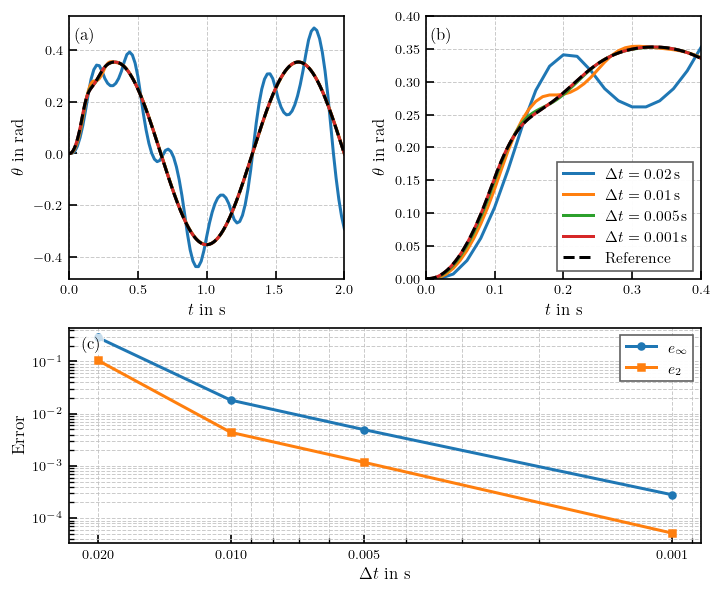

In [101]:
# Thesis figure: baseline convergence against the monolithic Modelica reference
from pathlib import Path
from matplotlib.ticker import ScalarFormatter

try:
    repo_root = _repo
except NameError:
    repo_root = Path.cwd()
    while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
        repo_root = repo_root.parent

# Normalize dictionary keys because the simulations above store step sizes as strings.
dt_keys = sorted(results.keys(), key=float, reverse=True)
dt_values_float = np.array([float(dt) for dt in dt_keys])

fig = plt.figure(figsize=(FULL_WIDTH, 0.82 * FULL_WIDTH), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.82])
ax_full = fig.add_subplot(gs[0, 0])
ax_zoom = fig.add_subplot(gs[0, 1])
ax_err = fig.add_subplot(gs[1, :])

for dt in dt_keys:
    history = results[dt]
    t_cs = np.asarray(history["Pendulum"][0], dtype=float)
    theta_cs = np.asarray(history["Pendulum"][1]["theta"], dtype=float)
    label = rf"$\Delta t={float(dt):g}\,\mathrm{{s}}$"
    ax_full.plot(t_cs, theta_cs, label=label)
    ax_zoom.plot(t_cs, theta_cs, label=label)

ax_full.plot(
    ref_sol["time"],
    ref_sol["theta"],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Reference",
)
ax_zoom.plot(
    ref_sol["time"],
    ref_sol["theta"],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="Reference",
)

ax_full.set_xlim(0.0, 2.0)
ax_zoom.set_xlim(0.0, 0.4)
ax_zoom.set_ylim(0.0, 0.4)
for ax in (ax_full, ax_zoom):
    ax.set_xlabel(r"$t$ in $\mathrm{s}$")
    ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
    ax.grid(True)

ax_zoom.legend(loc="lower right", ncol=1)

# Reuse the metrics computed above and show convergence under macro-step refinement.
e_inf = np.array([error_metrics[dt]["e_inf"] for dt in dt_keys], dtype=float)
e_2 = np.array([error_metrics[dt]["e_2"] for dt in dt_keys], dtype=float)

ax_err.loglog(dt_values_float, e_inf, marker="o", label=r"$e_\infty$")
ax_err.loglog(dt_values_float, e_2, marker="s", label=r"$e_2$")
ax_err.invert_xaxis()
ax_err.set_xlabel(r"$\Delta t$ in $\mathrm{s}$")
ax_err.set_ylabel("Error")
ax_err.set_xticks(dt_values_float)
ax_err.xaxis.set_major_formatter(ScalarFormatter())
ax_err.grid(True, which="both")
ax_err.legend(loc="upper right")

for label, ax in [("(a)", ax_full), ("(b)", ax_zoom), ("(c)", ax_err)]:
    ax.text(
        0.02,
        0.96,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5),
    )

out = repo_root / "thesis" / "figures" / "6_case_study" / "controlled_pendulum" / "validation"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "baseline_step_convergence.pdf")
fig.savefig(out / "baseline_step_convergence.png", dpi=300)
plt.show()
